In [1]:
# THIS CODE USES CUPY; FOR MORE THAN 500 GRIDPOINTS
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from PIL import Image
from numba import jit, prange

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
from scipy.signal import find_peaks
from scipy.integrate import quad
from scipy.optimize import root_scalar
from matplotlib.animation import PillowWriter, FuncAnimation
import ipywidgets as widgets
from IPython.display import display

print("Fin")

Fin


In [2]:
# Independent parameters (free to edit)

Na = 0.5 # Units: M 
T = 303.15 # Units: K
valence = 4
duration = 250 * 10**5 # In timesteps of dt
gridpoints = 1024 # Number of points
dx = 10 # Units: nm
dt = 1.E-5 # Units: sec
rho_mean = 9E-5 # Initial mean density of nanostar A, found by spinodal (rho dense + rho dilute)/2 for the value of T used
save_interval = 10**5

grid_length = dx * gridpoints # Total length (nm)
inv_dx2 = 1.0 / (dx * dx)

# Establishes constants
K = 1.0E6 # Units: nm^5 
M = 1 # Units: (nm s)^-1
B2 = 2190 # Units: nm^3
vb = 1.66 # Units: nm^3
kB = 1.314E-23 * 0.24 # Units: cal/K (1J=0.24cal)
mol = 6.02E23
dHa = -42000 # Units: cal/mol 
dS1 = 1.84 * cp.log(Na) # Units: cal/mol K
dS0 = -120 # Units: cal/mol K at 1M NaCl
floor = 1E-12 # Minimum value for arrays
num_saves = duration // save_interval + 1 # Number of saved values

Da = vb * cp.exp(-(dHa - T * (dS0 + dS1)) / (mol * kB * T))
Db = Da

print("Fin")

Fin


In [4]:
# Initializes array of density values
cp.random.seed(7) # Opens a random number generator instance, seed 7

rho = rho_mean * (1.0 + 0.01 * cp.random.uniform(low=-1, high=1, size=(gridpoints, gridpoints))) # Creates rho values around the mean with slight randomness
rho = cp.maximum(rho, 1.E-10) # Prevents negative densities

initial_mass = cp.sum(rho)

def laplacian_2d(function_array):
    """
    Computes the 2D Laplacian of a function, given an array representing that function
    """
    return ( #Uses the inbuilt roll which does allow for periodic boundary conditions
        cp.roll(function_array,  1, axis=1) +
        cp.roll(function_array, -1, axis=1) +
        cp.roll(function_array,  1, axis=0) +
        cp.roll(function_array, -1, axis=0) -
        4.0 * function_array) * inv_dx2

beta_mu_kernel = cp.ElementwiseKernel(
    'float64 rho, float64 lap_rho',
    'float64 output',
    f'''
    output = 2.0 * {B2} * rho
          + log(rho)
          + {valence} * log((-1.0 + sqrt(1.0 + 16.0 * rho * {Da})) / (8.0 * rho * {Da}))
          - {K} * lap_rho;
    ''',
    'beta_mu_kernel'
)

def compute_step_single(rho):

    lap_rho = laplacian_2d(rho)
    
    # Total chemical potential (with floored rho, Xa)
    beta_mu_total = beta_mu_kernel(rho, lap_rho)

    laplacian_2d_mu = laplacian_2d(beta_mu_total)


    return dt * M * laplacian_2d_mu


# Initializes arrays for saving rho
num_saves = duration // save_interval + 1
rho_total_array = cp.zeros((num_saves, gridpoints, gridpoints)) # Third dimension added for 2D grid
rho_total_array[0] = rho
save_index = 1

# Tracks the mass over time to ensure conservation
mass_history = []
time_history = []


for step in range(duration):

    # Iterates to find new value of rho
    rho += compute_step_single(rho)

    # Adds the new density to the array of densities + checks mass conservation every 10^6 steps
    if step % (save_interval) == 0:
        rho_total_array[save_index] = rho
        save_index += 1

        total_mass = cp.sum(rho)

        mass_history.append(total_mass)
        time_history.append(step * dt)

        rho = cp.maximum(rho, floor)

        print(f"Progress: {(step/(save_interval))} out of {duration/(save_interval)}")

Progress: 0.0 out of 250.0
Progress: 1.0 out of 250.0
Progress: 2.0 out of 250.0
Progress: 3.0 out of 250.0
Progress: 4.0 out of 250.0
Progress: 5.0 out of 250.0
Progress: 6.0 out of 250.0
Progress: 7.0 out of 250.0
Progress: 8.0 out of 250.0
Progress: 9.0 out of 250.0
Progress: 10.0 out of 250.0
Progress: 11.0 out of 250.0
Progress: 12.0 out of 250.0
Progress: 13.0 out of 250.0
Progress: 14.0 out of 250.0
Progress: 15.0 out of 250.0
Progress: 16.0 out of 250.0
Progress: 17.0 out of 250.0
Progress: 18.0 out of 250.0
Progress: 19.0 out of 250.0
Progress: 20.0 out of 250.0
Progress: 21.0 out of 250.0
Progress: 22.0 out of 250.0
Progress: 23.0 out of 250.0
Progress: 24.0 out of 250.0
Progress: 25.0 out of 250.0
Progress: 26.0 out of 250.0
Progress: 27.0 out of 250.0
Progress: 28.0 out of 250.0
Progress: 29.0 out of 250.0
Progress: 30.0 out of 250.0
Progress: 31.0 out of 250.0
Progress: 32.0 out of 250.0
Progress: 33.0 out of 250.0
Progress: 34.0 out of 250.0
Progress: 35.0 out of 250.0
Pr

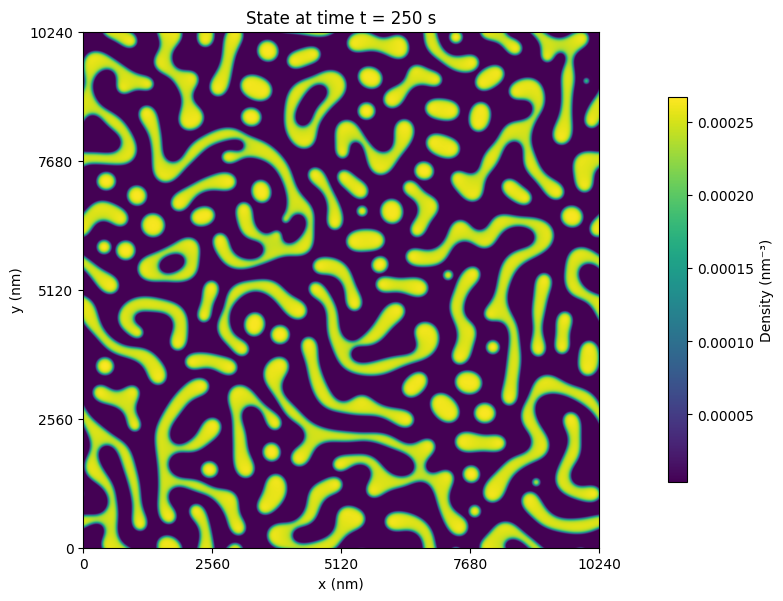

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))
rho_np = rho_total_array.get()

vmin, vmax = rho_np.min(), rho_np.max()
t_final = (save_index - 1) * save_interval * dt

im = ax.imshow(rho_np[save_index - 1], origin='lower', cmap='viridis',
               vmin=vmin, vmax=vmax,
               extent=[0, grid_length, 0, grid_length])
fig.colorbar(im, ax=ax, label="Density (nm⁻³)", shrink = 0.5, pad = 0.1)
ax.set_title(f"State at time t = {t_final:.0f} s")
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_xticks([0, grid_length/4, grid_length/2, (3*grid_length)/4, grid_length])
ax.set_yticks([0, grid_length/4, grid_length/2, (3*grid_length)/4, grid_length])


plt.tight_layout()
plt.savefig("rho_final.png", dpi=150)
plt.show()